In [1]:
# Import QUEER library
import queer
from queer import *
from queer.utils import path_create

import matplotlib.pyplot as plt
import numpy as np
from queer.mesh import mesh_crystal,mesh_cartesian,cartesian2crystal,crystal2cartesian

In [2]:
# Input files
file_path = "./examples/input/"
nscf = "nscf.out"
# wout = "NbSe2.wout"
hr = "wannier_hr.dat"

# Number of k points along the path

# Energy axis limits
ylim = [-2, 2]

model = queer.model(hr, file_path, nscf,read_ef=True)

In [3]:
k_points = 800
custom_points = [
    [1/2, 0, 0],   # M
    [0, 0, 0],     # Gamma
    [1/2, 0, 0],   # M
    [1/3, 1/3, 0], # K
    [0, 0, 0],      # Back to Gamma
    [1/3, 1/3, 0] # K
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['M','Γ', 'M', 'K', 'Γ', 'K']

Calculating band structure...
Plotting band structure...


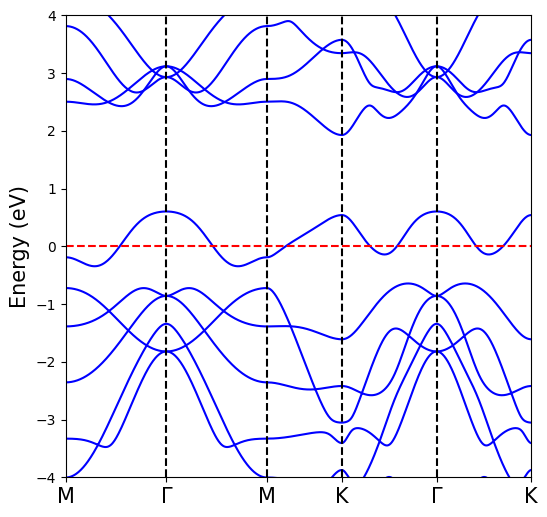

In [4]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])



In [5]:
model.g_vec

array([[1.80566391, 1.04250006, 0.        ],
       [0.        , 2.08500192, 0.        ],
       [0.        , 0.        , 0.45464812]])

In [6]:
g_vec = model.g_vec

In [7]:
cartesian = mesh_cartesian(N=[100,100,1])

In [8]:
crystal = mesh_crystal(N=[100,100,1],g_vec=g_vec)

In [9]:
energy = model.calculate_energy(cartesian)

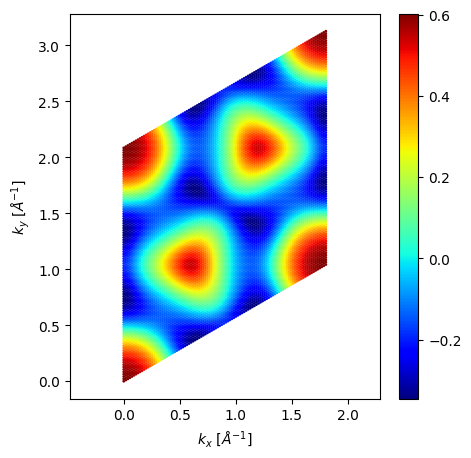

In [10]:
queer.plots.plot_electron_mesh(band=energy,mesh=crystal,metallic_band_index=6,s=1)

In [11]:
square = mesh_cartesian(N=[100,100,1],factor=3,gamma=True)

In [12]:
square_crystal= crystal2cartesian(square.T,g_vec)

In [13]:
energy_square = model.calculate_energy(square_crystal)

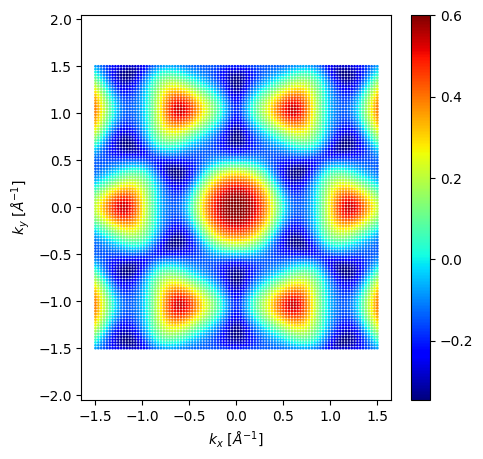

In [14]:
queer.plots.plot_electron_mesh(band=energy_square,mesh=square.T,metallic_band_index=6)

In [15]:
from queer.arpes import arpes_mesh,arpes_mesh_plot,k_array

In [71]:
light_energy = 21.2
binding_energy = 0.2
V0 = 10
N = 100
factor = 4


In [76]:
binding_array = np.arange(0.5,3.1,0.5)

In [77]:
binding_array

array([0.5, 1. , 1.5, 2. , 2.5, 3. ])

In [78]:
kmesh_dict = k_array(light_energy,binding_array,V0,N,factor)

/scratch/s.sevim/Dev/queer/queer/arpes.py:32: RuntimeWarning: invalid value encountered in sqrt
  kz = np.sqrt(C * (Ek + V0) - kx**2 - ky**2)


In [85]:
energy_dict = {}
for i,j in kmesh_dict.items():
    kmesh = np.array(j)
    # print(kmesh)
    inv_kmesh = crystal2cartesian(kmesh,g_vec)
    band = model.calculate_energy(inv_kmesh)
    energy_dict[i] =band
    # queer.plots.plot_electron_mesh(band=band,mesh=kmesh,metallic_band_index=6)
    # print(inv_kmesh)

[[-2.         -2.         -2.         ...  2.          2.
   2.        ]
 [-2.         -1.95959596 -1.91919192 ...  1.91919192  1.95959596
   2.        ]
 [ 0.24238399  0.46768972  0.61274169 ...  0.61274169  0.46768972
   0.24238399]]
[[-2.         -2.         -2.         ...  2.          2.
   2.        ]
 [-1.95959596 -1.91919192 -1.87878788 ...  1.87878788  1.91919192
   1.95959596]
 [ 0.29577639  0.49416837  0.6305998  ...  0.6305998   0.49416837
   0.29577639]]
[[-2.         -2.         -2.         ...  2.          2.
   2.        ]
 [-1.91919192 -1.87878788 -1.83838384 ...  1.83838384  1.87878788
   1.91919192]
 [ 0.33608388  0.51614543  0.6454416  ...  0.6454416   0.51614543
   0.33608388]]
[[-2.         -2.         -2.         ...  2.          2.
   2.        ]
 [-1.87878788 -1.83838384 -1.7979798  ...  1.7979798   1.83838384
   1.87878788]
 [ 0.36763583  0.53417681  0.6574714  ...  0.6574714   0.53417681
   0.36763583]]
[[-2.         -2.         -2.         ...  2.          2

In [83]:
energy

[array([[-4.73957771, -4.69778777, -4.64143272, ..., -4.64143376,
         -4.69778819, -4.7395758 ],
        [-4.01499014, -3.96767125, -3.90303005, ..., -3.90303056,
         -3.96767038, -4.01498914],
        [-3.29542442, -3.2981734 , -3.30420458, ..., -3.30420269,
         -3.29817217, -3.29542606],
        ...,
        [ 2.92427016,  2.88096227,  2.83323415, ...,  2.83323398,
          2.88096193,  2.92427012],
        [ 3.79736962,  3.72044132,  3.63423652, ...,  3.63423674,
          3.72044138,  3.79737042],
        [ 4.16882814,  4.20880871,  4.24293511, ...,  4.2429354 ,
          4.20880674,  4.16882873]], shape=(11, 10000)),
 array([[-4.69778777, -4.64143272, -4.57192801, ..., -4.57192936,
         -4.64143376, -4.69778819],
        [-3.96767125, -3.90303005, -3.82187646, ..., -3.82187796,
         -3.90303056, -3.96767038],
        [-3.2981734 , -3.30420458, -3.31523884, ..., -3.31523949,
         -3.30420269, -3.29817217],
        ...,
        [ 2.88096227,  2.83323415, 